기술적 EDA

In [1]:
# PostgreSQL에서 clean_orders 데이터 불러오기
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import urllib.parse

load_dotenv('.env')  # .env 파일 읽기

# DB연결정보
user = "postgres"
password = urllib.parse.quote_plus(os.getenv('DB_PW'))
host = "127.0.0.1"
port = '5432'
database = 'ecommerce'

# 엔진 생성
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')

# 데이터 불러오기
data = pd.read_sql("select * from clean_orders", engine)

In [10]:
# 데이터프레임 크기 확인
data.shape

(171, 6)

In [ ]:
# 컬럼별 자료형
data.info()

# item_total, cod에서 결측치 존재

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_no      171 non-null    object        
 1   buyer         171 non-null    object        
 2   order_date    171 non-null    datetime64[ns]
 3   item_total    153 non-null    float64       
 4   order_status  171 non-null    object        
 5   cod           147 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 8.1+ KB


In [ ]:
# 결측치 체크 => item_total / cod에 결측치 존재
data.isnull().sum()

# item_total 결측치 비율 확인
order_completed = data[data['order_status']=='Delivered to buyer']
item_total_null = order_completed['item_total'].isnull().sum()
item_total_null_ratio = (item_total_null/len(order_completed['item_total'])) * 100
print(item_total_null_ratio)

4.375


order_status가 Delivered to buyer인 것 기준으로 item_total 결측치 약 4프로 => 제거해도 무방하다고 판단하여 제거함

In [20]:
df = order_completed.dropna(subset=['item_total'])

In [21]:
# 숫자형 컬럼 체크
df.describe()

,order_date,item_total
count,153,153.000000
mean,2021-11-05 15:22:03.921568768,582.856209
min,2021-06-13 19:08:00,175.000000
25%,2021-09-20 18:41:00,399.000000
50%,2021-11-13 19:37:00,449.000000
75%,2021-12-15 11:11:00,549.000000
max,2022-02-25 20:44:00,3897.000000
std,NaN,488.100122


In [23]:
# 중복 확인
# 주문번호 기준
print(df['order_no'].duplicated().sum())

# 고객이름 + 주문날짜 기준
print(df.duplicated(subset=['buyer','order_date']).sum())


0
0


In [24]:
# 날짜 범위 확인
# 시작/끝 날짜 확인
print(df['order_date'].max())
print(df['order_date'].min())

# 연-월 단위로 확인
df['year_month'] = df['order_date'].dt.to_period('M')
print(df['year_month'].unique())

2022-02-25 20:44:00
2021-06-13 19:08:00
<PeriodArray>
['2021-07', '2021-10', '2021-11', '2021-09', '2021-06', '2021-08', '2022-02',
 '2022-01', '2021-12']
Length: 9, dtype: period[M]


C:\Users\82104\AppData\Local\Temp\ipykernel_13052\1715375098.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['order_date'].dt.to_period('M')


비즈니스 탐색 EDA

가설 1. 매출은 소수 고객에게 집중되어 있을 것

가설 2. 연말 소비 증가로 월 평균 대비 매출이 높을 것

가설 3. 재구매 고객은 전체 매출에서 높은 비중을 차지할 것

In [27]:
import matplotlib.pyplot as plt
import numpy as np

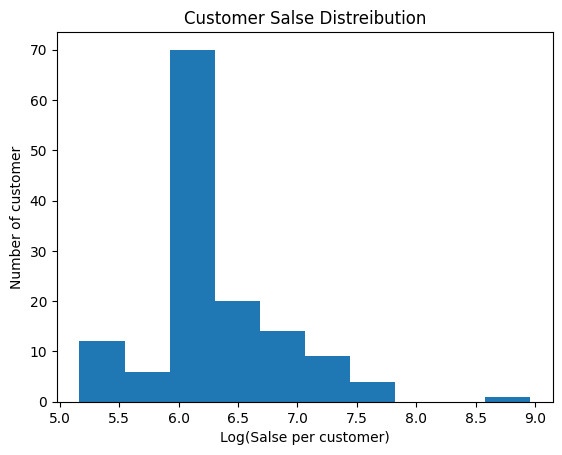

buyer
A                   57.730512
A.Jayaprada         23.585987
ANIL                57.730512
Aarti               64.964912
Abhishek           103.684000
                      ...    
swagata13051978    103.684000
swati               64.964912
veena               47.214936
vvijayakakshmi      64.964912
yatipertin          57.730512
Name: item_total, Length: 136, dtype: float64


In [ ]:
# 가설 1에 대한 비즈니스 탐색 EDA 진행 
customer_sales = df.groupby('buyer')['item_total'].sum()
reset_index_customer_sales = customer_sales.reset_index()

# 고객별 매출 분포 그래프
plt.figure()
plt.hist(np.log(reset_index_customer_sales['item_total']))
plt.xlabel('Log(Salse per customer)')
plt.ylabel('Number of customer')
plt.title('Customer Salse Distreibution')

plt.show()

# 상위 10% 고객 매출 비중 계산(수정필요)
sort_customer_sales = customer_sales.sort_values(ascending=False)

top_ten = int(len(sort_customer_sales)*0.1)

top_customer = sort_customer_sales.iloc[:top_ten].sum()

top_ten_ratio = top_customer / customer_sales

print(top_ten_ratio)

